hiposenter inversi:
[[ 1000.0095765 ]
 [-5500.00912782]]
Error: 0.0000036178


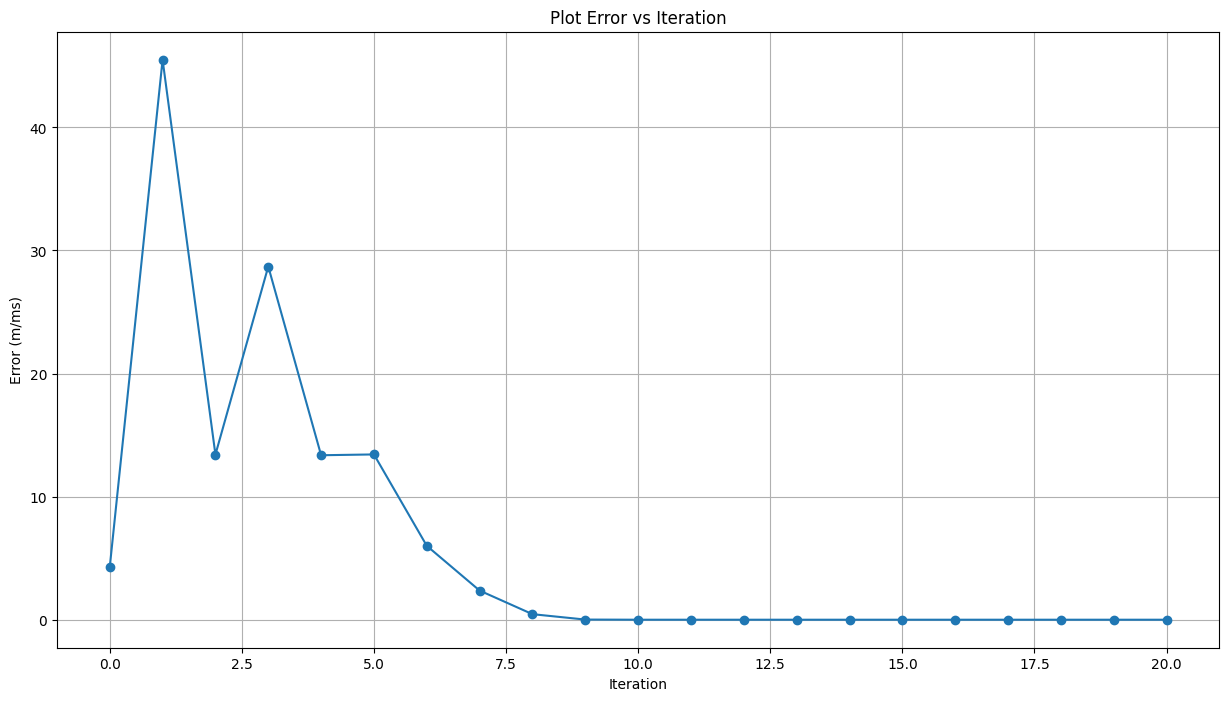

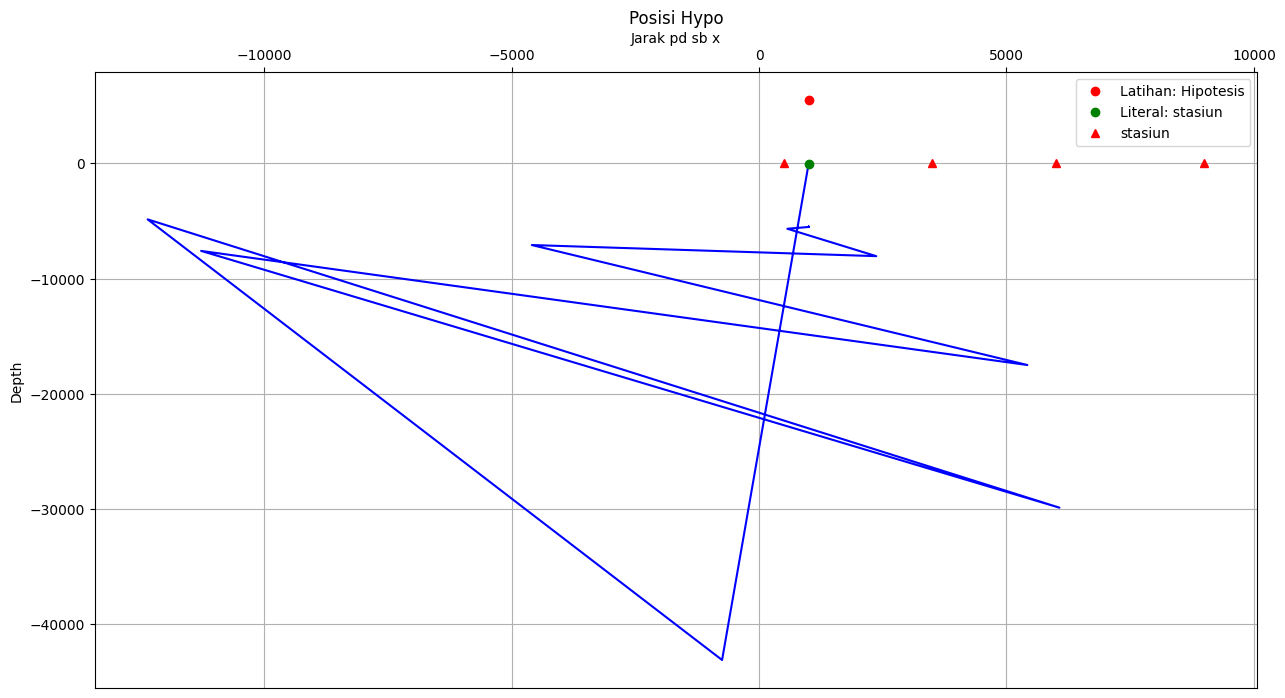

In [6]:
import numpy as np                                  # import library numpy untuk operasi numerik dan array
import matplotlib.pyplot as plt                     # import library matplotlib untuk membuat grafik
from numpy.linalg import inv                        # import fungsi invers matriks dari numpy

# forward model
def forward_model(x, z, m, v):                      # fungsi untuk menghitung waktu tempuh teoritis gelombang
    t = []                                          # membuat list kosong untuk menyimpan waktu tempuh
    for i in range(len(x)):                         # looping untuk setiap stasiun pengamatan
        t.append(np.sqrt((m[0] - x[i])**2 + (m[1] - z[i])**2) / v)  # menghitung waktu tempuh = jarak/kecepatan
    return np.array(t).reshape(len(t), 1)          # mengubah hasil menjadi array kolom lalu mengembalikan nilainya


def jacobian(x, z, m, v):                           # fungsi untuk menghitung matriks Jacobian
    J = np.zeros((len(x), 2))                       # membuat matriks nol ukuran jumlah stasiun x 2 parameter model
    for i in range(len(x)):                         # looping untuk setiap stasiun
        J[i, 0] = ((m[0].item() - x[i]) / np.sqrt((m[0].item() - x[i])**2 + (m[1].item() - z[i])**2))/v   # turunan parsial terhadap koordinat x
        J[i, 1] = ((m[1].item() - z[i]) / np.sqrt((m[0].item() - x[i])**2 + (m[1].item() - z[i])**2))/v   # turunan parsial terhadap koordinat z
    return J                                        # mengembalikan matriks Jacobian


def rmse(d, g_m):                                   # fungsi untuk menghitung Root Mean Square Error (RMSE)
    return np.sqrt(np.sum((g_m - d)**2) / len(d))  # menghitung error antara data observasi dan data sintetik


def inversi_linier(st_x, st_z, m, v, d, iterasi):  # fungsi utama inversi linier
    i = 0                                           # inisialisasi iterasi awal
    J = jacobian(st_x, st_z, m, v)                 # menghitung Jacobian awal
    g_m = forward_model(st_x, st_z, m, v)          # menghitung forward model awal
    g_m = g_m.reshape(len(g_m), 1)                 # memastikan bentuk array kolom
    
    error_history = []                             # list untuk menyimpan riwayat error
    error = rmse(g_m, d)                           # menghitung error awal
    error_history.append(error)                    # menyimpan error awal
    
    m_history = [m.reshape(2, 1)]                  # menyimpan model awal
    i_history = []                                 # list untuk menyimpan riwayat iterasi
    i_history.append(i)                            # menyimpan iterasi awal

    for i in range(iterasi):                       # looping proses inversi sebanyak jumlah iterasi
        i += 1                                     # menambah nomor iterasi
        i_history.append(i)                        # menyimpan nomor iterasi
        
        m = m.reshape(2, 1) + inv(J.T @ J) @ J.T @ (d - g_m)   # update model dengan metode least squares
        
        J = jacobian(st_x, st_z, m, v)            # menghitung Jacobian baru
        g_m = forward_model(st_x, st_z, m, v)     # menghitung forward model baru
        g_m = g_m.reshape(len(g_m), 1)            # memastikan bentuk array kolom
        
        error = rmse(d, g_m)                      # menghitung error baru
        error_history.append(error)               # menyimpan error
        
        m_history.append(m)                       # menyimpan model setiap iterasi
        
    return m, m_history, error_history, i_history # mengembalikan model akhir, history model, error, dan iterasi


# posisi stasiun
st_x = np.array([500, 3500, 6000, 9000])          # koordinat x masing-masing stasiun
st_z = np.array([0, 0, 0, 0])                     # koordinat z masing-masing stasiun (permukaan)

# data observasi (waktu gelombang)
waktu_gel = np.array([6.9033664, 7.55190373, 9.29129297, 12.13530491])   # data waktu tempuh hasil observasi
d = waktu_gel.reshape(len(waktu_gel), 1)          # mengubah data observasi menjadi array kolom
v = 800                                           # kecepatan gelombang seismik (m/s)

# tebakan awal
m0 = np.array([1000, -80])                        # model awal hiposenter [x,z]
iterasi = 20                                      # jumlah iterasi inversi
E = 0.001                                         # toleransi error (belum digunakan)
I = np.eye(2)                                     # matriks identitas 2x2 (belum digunakan)

# inversi linier
hypo, hypo_history, error_history, iterasi_history = inversi_linier(st_x, st_z, m0, v ,d, iterasi)   # menjalankan inversi linier

print('hiposenter inversi:')                      # menampilkan teks hasil
print(hypo)                                       # menampilkan koordinat hiposenter hasil inversi
print(f'Error: {error_history[-1]:.10f}')         # menampilkan error akhir

plt.figure(figsize=(15, 8))                       # membuat figure grafik error ukuran 15x8
plt.plot(iterasi_history, error_history, 'o-')   # memplot error terhadap iterasi
plt.title('Plot Error vs Iteration')              # memberi judul grafik
plt.xlabel('Iteration')                           # memberi label sumbu x
plt.ylabel('Error (m/ms)')                        # memberi label sumbu y
plt.grid()                                        # menampilkan grid
plt.show()                                        # menampilkan grafik error

hypo_history_array = np.array(hypo_history)       # mengubah history model menjadi array numpy

plt.figure(figsize=(15, 8))                       # membuat figure grafik posisi hiposenter
plt.plot(hypo_history_array[:, 0], hypo_history_array[:, 1], 'b-')   # memplot jalur perubahan posisi hiposenter
plt.plot(1000, 5500, 'o', color='red', label='Latihan: Hipotesis')   # menampilkan titik hiposenter sebenarnya
plt.plot(m0[0], m0[1], 'o', color='green', label='Literal: stasiun') # menampilkan tebakan awal
plt.plot(st_x, st_z, '^', color='red', label='stasiun')              # menampilkan posisi stasiun
plt.title('Posisi Hypo')                         # memberi judul grafik
plt.xlabel('Jarak pd sb x')                      # memberi label sumbu x
plt.ylabel('Depth')                              # memberi label sumbu y
plt.legend()                                     # menampilkan legenda
plt.grid()                                       # menampilkan grid
plt.gca().xaxis.set_label_position('top')       # memindahkan label sumbu x ke atas
plt.gca().xaxis.tick_top()                      # memindahkan angka sumbu x ke atas
plt.show()                                       # menampilkan grafik posisi hiposenter


HASIL
True Hypo : (12, 10)
Estimasi  : (11.8331, 9.9274)
Error     : 0.016316


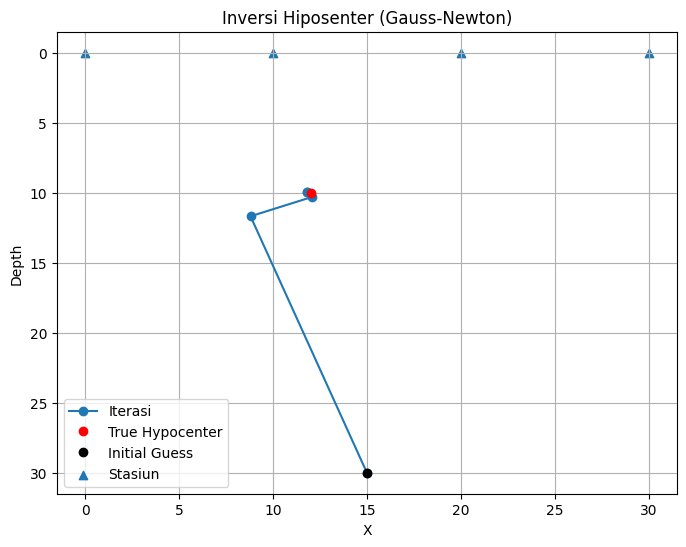

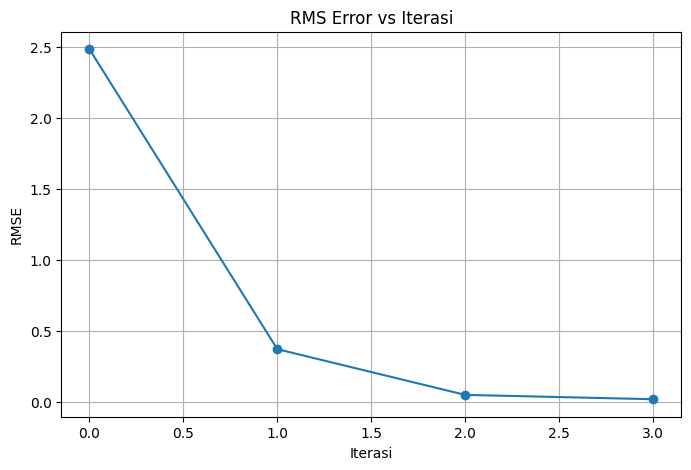

In [7]:
# permasalahan 1
import numpy as np                                  # import library numpy untuk operasi numerik dan array
import matplotlib.pyplot as plt                     # import library matplotlib untuk visualisasi grafik

# DATA
x = np.array([0, 10, 20, 30])                      # koordinat x masing-masing stasiun pengamatan
z = np.array([0, 0, 0, 0])                         # koordinat z masing-masing stasiun (semua di permukaan)
n = len(x)                                         # menghitung jumlah stasiun

# True hypocenter
xo, zo, t0 = 12, 10, 0                             # menentukan hiposenter sebenarnya (x, z) dan origin time
v = 7                                              # kecepatan rambat gelombang seismik

# FORWARD MODEL
def forward(x, z, m):                              # fungsi untuk menghitung waktu tempuh teoritis
    t = []                                         # membuat list kosong untuk menyimpan waktu tempuh
    for i in range(n):                             # looping untuk setiap stasiun
        r = np.sqrt((x[i] - m[0])**2 + (z[i] - m[1])**2)   # menghitung jarak sumber ke stasiun
        t.append(r / v)                            # menghitung waktu tempuh = jarak / kecepatan
    return np.array(t)                             # mengubah hasil menjadi array numpy

# data observasi
t_true = forward(x, z, [xo, zo])                  # menghitung data sintetik berdasarkan hiposenter sebenarnya

# noise 1%
noise = np.random.normal(0, 0.01*np.mean(t_true), n)   # membuat noise acak sebesar 1% dari rata-rata waktu tempuh
t_obs = t_true + noise                            # menambahkan noise ke data sintetik sehingga menjadi data observasi

# JACOBIAN
def jacobian(x, z, m):                            # fungsi untuk menghitung matriks Jacobian
    J = np.zeros((n, 2))                          # membuat matriks nol ukuran jumlah stasiun x 2 parameter model
    for i in range(n):                            # looping untuk setiap stasiun
        r = np.sqrt((x[i] - m[0])**2 + (z[i] - m[1])**2)   # menghitung jarak sumber ke stasiun
        J[i,0] = (-(x[i] - m[0])) / (v * r)      # turunan parsial terhadap parameter x
        J[i,1] = (-(z[i] - m[1])) / (v * r)      # turunan parsial terhadap parameter z
    return J                                      # mengembalikan matriks Jacobian

# RMSE
def rmse(d, g):                                   # fungsi untuk menghitung Root Mean Square Error
    return np.sqrt(np.mean((d - g)**2))          # menghitung rata-rata akar kuadrat selisih data observasi dan sintetik

# INVERSI GAUSS-NEWTON
m = np.array([15, 30])                           # menentukan tebakan awal hiposenter [x,z]
max_iter = 4                                     # menentukan jumlah maksimum iterasi
target_error = 1e-2                              # menentukan target error agar inversi berhenti jika sudah cukup kecil

m_hist = [m.copy()]                              # menyimpan riwayat model pada setiap iterasi
err_hist = []                                    # menyimpan riwayat error pada setiap iterasi

for i in range(max_iter):                        # looping inversi sebanyak jumlah iterasi maksimum
    g = forward(x, z, m)                         # menghitung data sintetik dari model saat ini
    J = jacobian(x, z, m)                        # menghitung matriks Jacobian model saat ini

    r = t_obs - g                                # menghitung residual (selisih data observasi dan sintetik)

    # update model
    dm = np.linalg.inv(J.T @ J) @ J.T @ r       # menghitung koreksi model dengan metode Gauss-Newton
    m = m + dm                                   # memperbarui model hiposenter

    # simpan
    m_hist.append(m.copy())                      # menyimpan model hasil update
    err = rmse(t_obs, g)                        # menghitung error RMSE
    err_hist.append(err)                        # menyimpan error

    if err < target_error:                      # mengecek apakah error sudah lebih kecil dari target
        print(f"Konvergen di iterasi ke-{i+1}") # menampilkan informasi konvergensi
        break                                   # menghentikan iterasi jika sudah konvergen

# OUTPUT
print("\nHASIL")                                # menampilkan judul hasil
print(f"True Hypo : ({xo}, {zo})")              # menampilkan hiposenter sebenarnya
print(f"Estimasi  : ({m[0]:.4f}, {m[1]:.4f})") # menampilkan hasil estimasi hiposenter
print(f"Error     : {err_hist[-1]:.6f}")       # menampilkan error akhir inversi

# PLOT
m_hist = np.array(m_hist)                       # mengubah riwayat model menjadi array numpy

plt.figure(figsize=(8,6))                      # membuat figure grafik posisi hiposenter
plt.plot(m_hist[:,0], m_hist[:,1], 'o-', label='Iterasi')   # memplot jalur perubahan model tiap iterasi
plt.plot(xo, zo, 'ro', label='True Hypocenter')             # menampilkan hiposenter sebenarnya
plt.plot(15, 30, 'ko', label='Initial Guess')               # menampilkan tebakan awal
plt.scatter(x, z, marker='^', label='Stasiun')              # menampilkan posisi stasiun

plt.xlabel('X')                                 # memberi label sumbu x
plt.ylabel('Depth')                             # memberi label sumbu y
plt.title('Inversi Hiposenter (Gauss-Newton)') # memberi judul grafik
plt.legend()                                    # menampilkan legenda
plt.grid()                                      # menampilkan grid
plt.gca().invert_yaxis()                        # membalik sumbu y agar kedalaman bertambah ke bawah
plt.show()                                      # menampilkan grafik posisi hiposenter

plt.figure(figsize=(8,5))                      # membuat figure grafik error
plt.plot(err_hist, 'o-')                       # memplot perubahan RMSE terhadap iterasi
plt.title('RMS Error vs Iterasi')              # memberi judul grafik
plt.xlabel('Iterasi')                          # memberi label sumbu x
plt.ylabel('RMSE')                             # memberi label sumbu y
plt.grid()                                     # menampilkan grid
plt.show()                                     # menampilkan grafik error

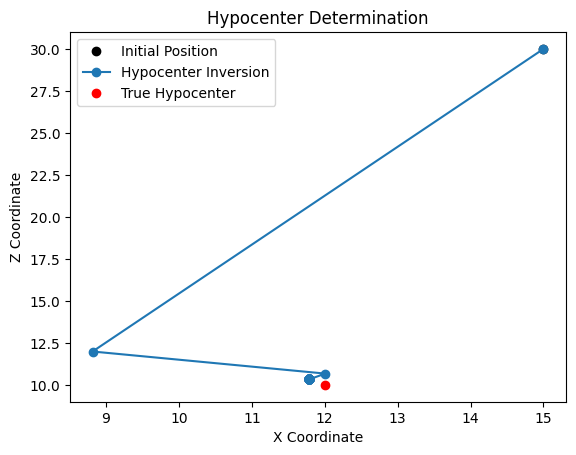

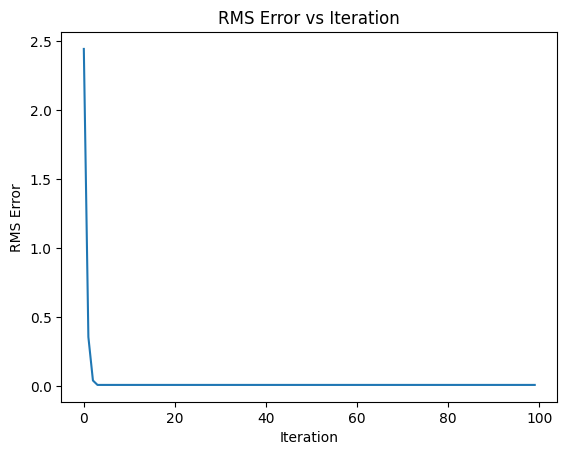

In [8]:
#permasalahan 2
import numpy as np                              # import library numpy untuk operasi matematis
import matplotlib.pyplot as plt                 # import library matplotlib untuk visualisasi grafik
import copy                                     # import library copy untuk menyalin data
from numpy.linalg import inv                    # import fungsi invers matriks dari numpy.linalg

# station position
x = [0, 10, 20, 30]                            # koordinat X stasiun
z = [0, 0, 0, 0]                               # koordinat Z stasiun
n = len(x)                                      # jumlah stasiun

# True hypocenter
xo = 12                                         # koordinat X hiposenter sebenarnya
zo = 10                                         # koordinat Z hiposenter sebenarnya
to = 0                                          # origin time gempa

# velocity
V = 7                                           # kecepatan gelombang seismik

# forward modelling (true travel time)
t = []                                          # list untuk menyimpan waktu tempuh teoritis
for i in range(n):                              # perulangan untuk setiap stasiun
    t.append((1/V)*np.sqrt((z[i]-zo)**2 + (x[i]-xo)**2))  # menghitung travel time teoritis

t = np.array(t)                                 # mengubah list menjadi array numpy

# add noise
noise = np.random.rand(n) * 0.03 * np.mean(t)  # membuat noise acak sebesar 3% dari rata-rata waktu tempuh

ti = t + noise                                  # menambahkan noise ke data travel time

# initial guess model
m = [15, 30]                                    # model awal hiposenter [x,z]

init_position = copy.deepcopy(m)                # menyimpan posisi awal model

# simpan hasil
xhipo = [m[0]]                                  # list untuk menyimpan koordinat X hasil inversi
yhipo = [m[1]]                                  # list untuk menyimpan koordinat Z hasil inversi

erms = []                                       # list untuk menyimpan RMS error

# iterasi inversi non-linear
for niter in range(100):                        # perulangan inversi sebanyak 100 iterasi

    gm = []                                     # list untuk menyimpan respon model
    dgm_dm1 = []                                # list turunan parsial terhadap parameter X
    dgm_dm2 = []                                # list turunan parsial terhadap parameter Z

    for i in range(n):                          # perulangan untuk setiap stasiun
        
        r = np.sqrt((x[i]-m[0])**2 + (z[i]-m[1])**2)  # menghitung jarak hiposenter ke stasiun

        gm.append(to + (1/V)*r)                 # menghitung travel time kalkulasi

        dgm_dm1.append((1/V)*(-(x[i]-m[0])/r)) # turunan parsial terhadap koordinat X
        
        dgm_dm2.append((1/V)*(-(z[i]-m[1])/r)) # turunan parsial terhadap koordinat Z

    gm = np.array(gm).reshape(n,1)              # mengubah gm menjadi matriks kolom

    ti_reshape = ti.reshape(n,1)                # mengubah data observasi menjadi matriks kolom

    # Jacobian
    J = np.zeros((n,2))                         # membuat matriks Jacobian kosong

    for i in range(n):                          # perulangan mengisi matriks Jacobian
        
        J[i,0] = dgm_dm1[i]                     # kolom pertama Jacobian
        
        J[i,1] = dgm_dm2[i]                     # kolom kedua Jacobian

    # update model (least squares)
    JTJ_inv = inv(J.T @ J)                      # menghitung invers matriks JTJ

    dm = JTJ_inv @ J.T @ (ti_reshape - gm)     # menghitung update model metode least squares

    m = [m[0] + dm[0,0], m[1] + dm[1,0]]       # memperbarui model hiposenter

    xhipo.append(m[0])                          # menyimpan koordinat X hasil inversi
    
    yhipo.append(m[1])                          # menyimpan koordinat Z hasil inversi

    # RMS error
    dt = ti_reshape - gm                        # menghitung residual data
    
    erms.append(np.sqrt(np.mean(dt**2)))        # menghitung RMS error

# plotting
plt.figure()                                    # membuat figure baru

plt.plot(init_position[0], init_position[1], 'o', label='Initial Position', color='black')  # plot posisi awal

plt.plot(xhipo, yhipo, 'o-', label='Hypocenter Inversion')  # plot jalur inversi hiposenter

plt.plot(xo, zo, 'o', color='red', label='True Hypocenter') # plot hiposenter sebenarnya

plt.title('Hypocenter Determination')           # judul grafik

plt.xlabel('X Coordinate')                      # label sumbu X

plt.ylabel('Z Coordinate')                      # label sumbu Z

plt.legend()                                    # menampilkan legenda

plt.figure()                                    # membuat figure baru

plt.plot(erms)                                  # plot RMS error

plt.title('RMS Error vs Iteration')             # judul grafik RMS

plt.xlabel('Iteration')                         # label sumbu iterasi

plt.ylabel('RMS Error')                         # label sumbu RMS error

plt.show()                                      # menampilkan seluruh grafik

Iterasi 1
Model [x, z, t]: [5.02218178 4.99366323 0.84948574]
Error: 2.077580
----------------------------------------
Iterasi 2
Model [x, z, t]: [5.04467794 4.98865184 0.71221605]
Error: 1.894410
----------------------------------------
Iterasi 3
Model [x, z, t]: [5.06728789 4.98515642 0.59105722]
Error: 1.753073
----------------------------------------
Iterasi 4
Model [x, z, t]: [5.08975184 4.9832842  0.48818395]
Error: 1.651704
----------------------------------------
Iterasi 5
Model [x, z, t]: [5.11181489 4.98301135 0.40431422]
Error: 1.583940
----------------------------------------
Iterasi 6
Model [x, z, t]: [5.13330132 4.98418221 0.33842212]
Error: 1.541031
----------------------------------------
Iterasi 7
Model [x, z, t]: [5.15414827 4.98655926 0.28815851]
Error: 1.514587
----------------------------------------
Iterasi 8
Model [x, z, t]: [5.17438691 4.98988719 0.25062387]
Error: 1.498184
----------------------------------------
Iterasi 9
Model [x, z, t]: [5.19410021 4.9939366

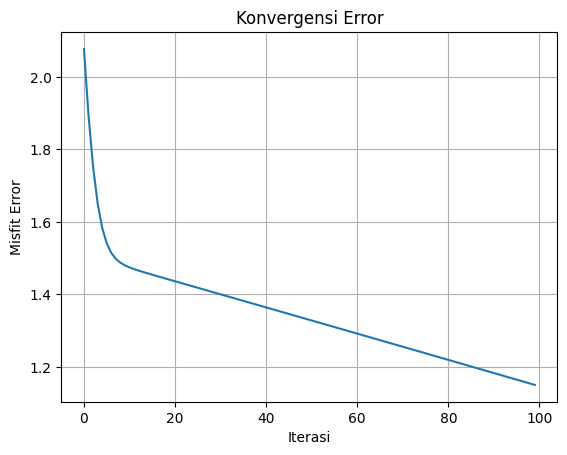

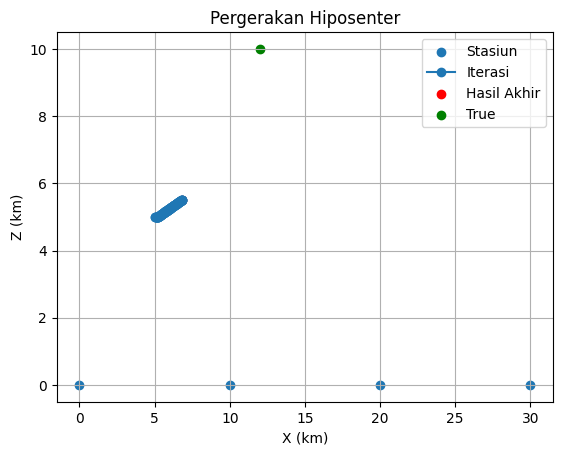

In [9]:
# permasalahan 2
import numpy as np                                  # import library numpy untuk operasi numerik dan array
import matplotlib.pyplot as plt                     # import library matplotlib untuk visualisasi grafik

# DATA DARI SOAL

# Posisi stasiun
x = np.array([0, 10, 20, 30])                      # koordinat x masing-masing stasiun pengamatan
z = np.array([0, 0, 0, 0])                         # koordinat z masing-masing stasiun (semua di permukaan)
n = len(x)                                         # menghitung jumlah stasiun

# True hiposenter (dipakai untuk buat data observasi)
xo = 12                                            # koordinat x hiposenter sebenarnya
zo = 10                                            # koordinat z (kedalaman) hiposenter sebenarnya
to = 0                                             # origin time (waktu awal gempa)

# Kecepatan gelombang
v = 7                                              # kecepatan rambat gelombang seismik

# MEMBUAT DATA OBSERVASI (FORWARD TRUE)
def true_travel_time(xo, zo, to):                  # fungsi untuk menghitung waktu tempuh observasi dari hiposenter sebenarnya
    t_obs = []                                     # membuat list kosong untuk menyimpan waktu tempuh
    
    for i in range(n):                             # looping untuk setiap stasiun
        d = np.sqrt((x[i] - xo)**2 + (z[i] - zo)**2)   # menghitung jarak hiposenter ke stasiun
        t = to + d / v                             # menghitung waktu tempuh = origin time + jarak/kecepatan
        t_obs.append(t)                            # menyimpan waktu tempuh
    
    return np.array(t_obs)                         # mengubah hasil menjadi array numpy

t_obs = true_travel_time(xo, zo, to)              # menghasilkan data observasi sintetik

# FORWARD MODELLING
def forward_model(m):                              # fungsi untuk menghitung waktu tempuh model
    xs, zs, ts = m                                 # memisahkan parameter model menjadi x, z, dan origin time
    t_model = []                                   # membuat list kosong untuk menyimpan waktu tempuh model
    
    for i in range(n):                             # looping untuk setiap stasiun
        d = np.sqrt((x[i] - xs)**2 + (z[i] - zs)**2)   # menghitung jarak model ke stasiun
        t = ts + d / v                             # menghitung waktu tempuh model
        t_model.append(t)                          # menyimpan waktu tempuh
    
    return np.array(t_model)                       # mengubah hasil menjadi array numpy

# MISFIT FUNCTION
def misfit(m):                                     # fungsi untuk menghitung error/misfit model
    t_model = forward_model(m)                     # menghitung data sintetik berdasarkan model
    return np.sqrt(np.sum((t_obs - t_model)**2))  # menghitung akar jumlah kuadrat selisih data observasi dan model

# GRADIEN NUMERIK
def gradient(m, h=1e-5):                           # fungsi untuk menghitung gradien numerik dengan metode beda hingga
    grad = np.zeros(3)                             # membuat array nol untuk gradien [x, z, t]
    
    for i in range(3):                             # looping untuk setiap parameter model
        m_plus = m.copy()                          # menyalin model awal untuk perturbasi positif
        m_minus = m.copy()                         # menyalin model awal untuk perturbasi negatif
        
        m_plus[i] += h                             # menambah parameter dengan nilai kecil h
        m_minus[i] -= h                            # mengurangi parameter dengan nilai kecil h
        
        grad[i] = (misfit(m_plus) - misfit(m_minus)) / (2*h)   # menghitung turunan numerik pusat
    
    return grad                                    # mengembalikan nilai gradien

# GRADIENT DESCENT
def gradient_descent(m_init, lr=0.1, max_iter=100):   # fungsi inversi menggunakan metode gradient descent
    m = m_init.copy()                              # menyalin tebakan awal model
    
    error_history = []                             # list untuk menyimpan riwayat error
    model_history = []                             # list untuk menyimpan riwayat model
    
    for i in range(max_iter):                      # looping sebanyak jumlah iterasi maksimum
        grad = gradient(m)                         # menghitung gradien model
        
        # Update model
        m = m - lr * grad                          # memperbarui model dengan langkah turun gradien
        
        err = misfit(m)                            # menghitung error model terbaru
        
        error_history.append(err)                  # menyimpan error
        model_history.append(m.copy())             # menyimpan model
        
        print(f"Iterasi {i+1}")                    # menampilkan nomor iterasi
        print(f"Model [x, z, t]: {m}")             # menampilkan parameter model saat ini
        print(f"Error: {err:.6f}")                 # menampilkan nilai error
        print("-"*40)                              # garis pemisah output
        
        if err < 1e-5:                             # jika error sangat kecil
            break                                  # menghentikan iterasi
    
    return m, error_history, model_history         # mengembalikan model akhir, riwayat error, dan riwayat model

# RUN INVERSI

# Tebakan awal
m_init = np.array([5.0, 5.0, 1.0])                # menentukan tebakan awal [x, z, origin time]

m_final, error_history, model_history = gradient_descent(
    m_init,                                        # memasukkan tebakan awal
    lr=0.1,                                       # learning rate (besar langkah update)
    max_iter=100                                  # jumlah iterasi maksimum
)

print("\n=== HASIL AKHIR ===")                    # menampilkan judul hasil akhir
print("Hiposenter hasil inversi:", m_final)       # menampilkan hiposenter hasil inversi
print("Hiposenter sebenarnya:", [xo, zo, to])     # menampilkan hiposenter sebenarnya

# PLOT ERROR
plt.figure()                                      # membuat figure baru
plt.plot(error_history)                           # memplot error terhadap iterasi
plt.xlabel("Iterasi")                             # memberi label sumbu x
plt.ylabel("Misfit Error")                        # memberi label sumbu y
plt.title("Konvergensi Error")                    # memberi judul grafik
plt.grid()                                        # menampilkan grid
plt.show()                                        # menampilkan grafik

# PLOT LOKASI HIPOSENTER
model_history = np.array(model_history)           # mengubah riwayat model menjadi array numpy

plt.figure()                                      # membuat figure baru
plt.scatter(x, z, label="Stasiun")                # menampilkan posisi stasiun
plt.plot(model_history[:,0], model_history[:,1], '-o', label="Iterasi")   # menampilkan jalur perubahan model
plt.scatter(m_final[0], m_final[1], color='red', label="Hasil Akhir")     # menampilkan hiposenter hasil akhir
plt.scatter(xo, zo, color='green', label="True") # menampilkan hiposenter sebenarnya

plt.xlabel("X (km)")                              # memberi label sumbu x
plt.ylabel("Z (km)")                              # memberi label sumbu y
plt.title("Pergerakan Hiposenter")                # memberi judul grafik
plt.legend()                                      # menampilkan legenda
plt.grid()                                        # menampilkan grid
plt.show()                                        # menampilkan grafik